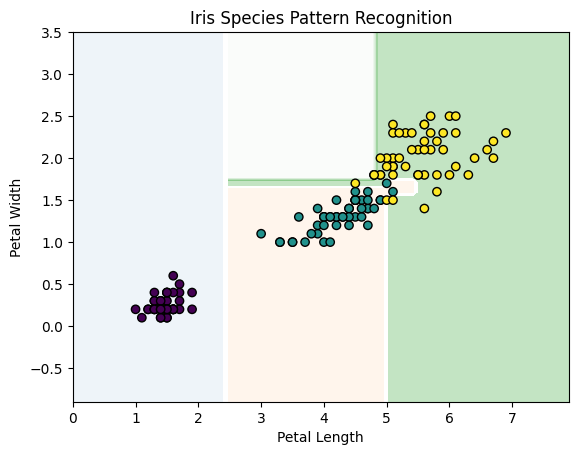

Accuracy: 0.9933333333333333
Prediction: 0


/Users/shivaai/Desktop/PRA CODES/vnev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Correct column names
X = df[['petal length (cm)', 'petal width (cm)']]
y, labels = pd.factorize(df['species'])

# Train model
model = DecisionTreeClassifier()
model.fit(X, y)

# Plot decision boundary
DecisionBoundaryDisplay.from_estimator(model, X, alpha=0.3)

plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c=y, edgecolor='black')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Species Pattern Recognition")
plt.show()

# Accuracy & prediction
print("Accuracy:", model.score(X, y))
print("Prediction:", labels[model.predict([[1.4, 0.2]])[0]])

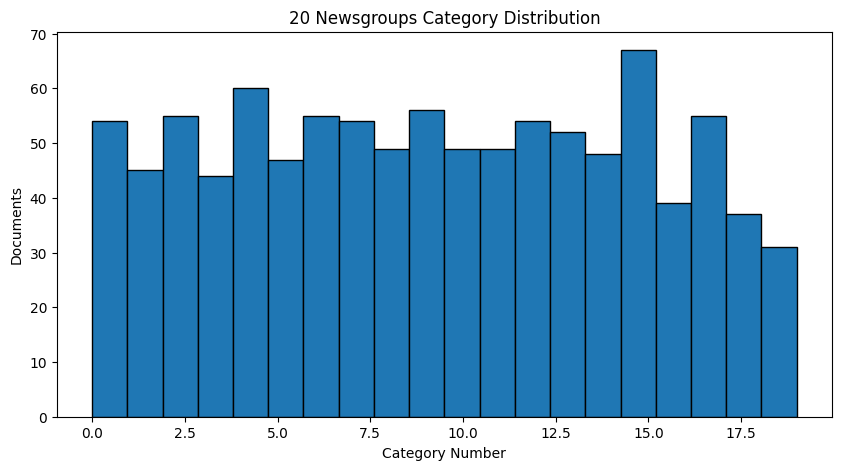

Accuracy: 0.899
Prediction: comp.sys.mac.hardware


In [4]:
# Q.2) 

import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

data = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)
labels = data.target_names

texts = data.data[:1000]
targets = data.target[:1000]

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(texts)

model = MultinomialNB()
model.fit(X, targets)
plt.figure(figsize=(10,5))
plt.hist(targets, bins=20, edgecolor='black')
plt.title("20 Newsgroups Category Distribution")
plt.xlabel("Category Number")
plt.ylabel("Documents")
plt.show()

print("Accuracy:", model.score(X, targets))
sample = ["The computer needs a better graphics card"]
sample_vec = vec.transform(sample)

res = model.predict(sample_vec)
print("Prediction:", labels[res[0]])

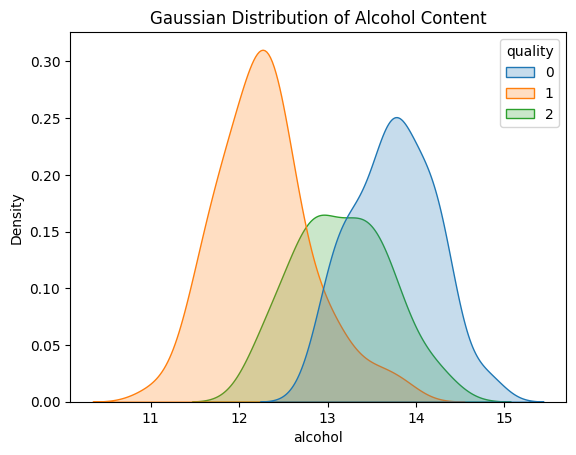

Model Accuracy: 0.9444444444444444
Predicted Quality for Sample: 0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine

# Load built-in dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['quality'] = wine.target   # similar to your original

# Features & target
X = df.drop('quality', axis=1)
y = df['quality']

# Train-test split
xt, xtst, yt, ytst = train_test_split(X, y, test_size=0.2)

# Model
model = GaussianNB().fit(xt, yt)

# Plot (similar idea: distribution)
sns.kdeplot(data=df, x='alcohol', hue='quality', fill=True, palette='tab10')
plt.title("Gaussian Distribution of Alcohol Content")
plt.show()

# Accuracy
print("Model Accuracy:", model.score(xtst, ytst))

# Prediction
sample = xtst.iloc[[0]]
prediction = model.predict(sample)

print(f"Predicted Quality for Sample: {prediction[0]}")

Accuracy: 0.6


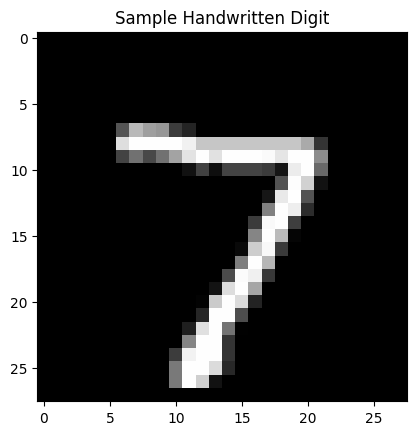

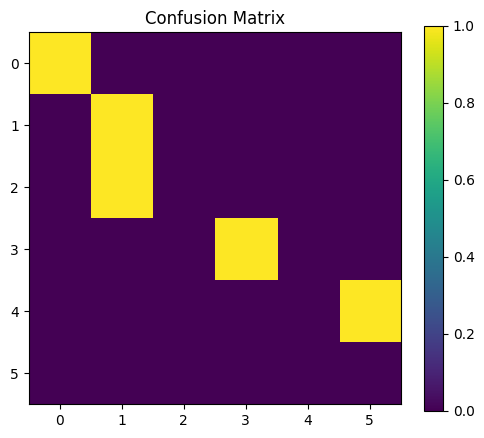

Predicted Digit: 9
Actual Digit: 7


/Users/shivaai/Desktop/PRA CODES/vnev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [6]:
# Q.4) Handwritten Digit Recognition using Bayes Theory

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

train = pd.read_csv("/Users/shivaai/Desktop/PRA CODES/4_mnist_train.csv").head()
test = pd.read_csv("/Users/shivaai/Desktop/PRA CODES/4_mnist_test.csv").head()
xt = train.drop("label", axis=1)
yt = train["label"]

xtt = test.drop("label", axis=1)
ytt = test["label"]
model = GaussianNB()
model.fit(xt, yt)
yp = model.predict(xtt)
print("Accuracy:", accuracy_score(ytt, yp))


img = xtt.values[0].reshape(28,28)
plt.imshow(img, cmap='gray')
plt.title("Sample Handwritten Digit")
plt.show()

cm = confusion_matrix(ytt, yp)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

print("Predicted Digit:", model.predict([xtt.values[0]])[0])
print("Actual Digit:", ytt.values[0])

Total Records: 3000
Anomalies Found: 300
Normal Records: 2700


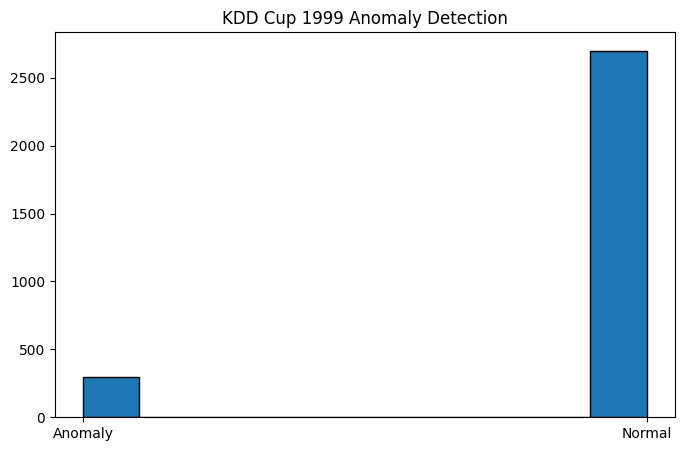

First 10 Predictions: [-1  1  1  1  1  1 -1  1  1  1]


In [7]:
# Q.5)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_kddcup99
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder


data = fetch_kddcup99(percent10=True)
df = pd.DataFrame(data.data).head(3000)
for col in df.columns:
    if df[col].dtype == object:
        df[col] = LabelEncoder().fit_transform(df[col])

model = IsolationForest(contamination=0.1)
model.fit(df)


pred = model.predict(df)     # -1 = anomaly, 1 = normal
print("Total Records:", len(pred))
print("Anomalies Found:", sum(pred == -1))
print("Normal Records:", sum(pred == 1))

plt.figure(figsize=(8,5))
plt.hist(pred, edgecolor='black')
plt.xticks([-1,1], ["Anomaly","Normal"])
plt.title("KDD Cup 1999 Anomaly Detection")
plt.show()

print("First 10 Predictions:", pred[:10])

Clinical Outcome Prediction Accuracy: 0.945010183299389


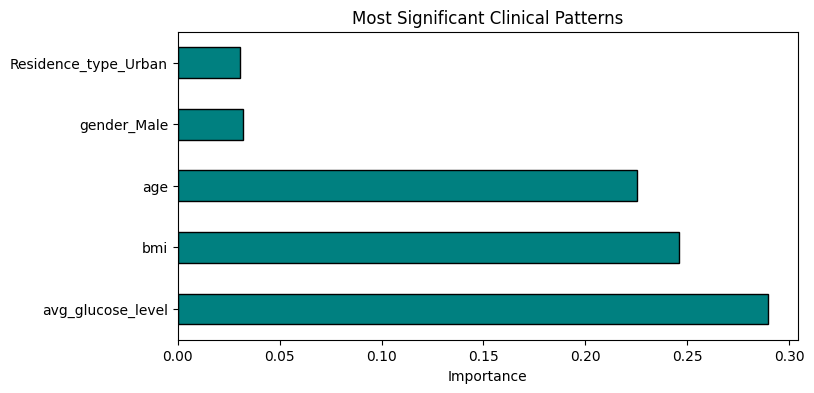

In [8]:
# Q.6)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


df = pd.read_csv("6_healthcare-dataset-stroke-data.csv")
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df = df.dropna()

X = pd.get_dummies(df.drop(['id', 'stroke'], axis=1), drop_first=True)
y = df['stroke']
xt, xtst, yt, ytst = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(xt, yt)
pred = model.predict(xtst)

print("Clinical Outcome Prediction Accuracy:", accuracy_score(ytst, pred))
imp = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,4))
imp.nlargest(5).plot(kind='barh', color='teal', edgecolor='black')
plt.title("Most Significant Clinical Patterns")
plt.xlabel("Importance")
plt.show()

P(No Lung Cancer): 9.587898814724325e-05
P(Yes Lung Cancer): 0.9999041210118539
Predicted Lung Cancer: 2


/Users/shivaai/Desktop/PRA CODES/vnev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
/Users/shivaai/Desktop/PRA CODES/vnev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


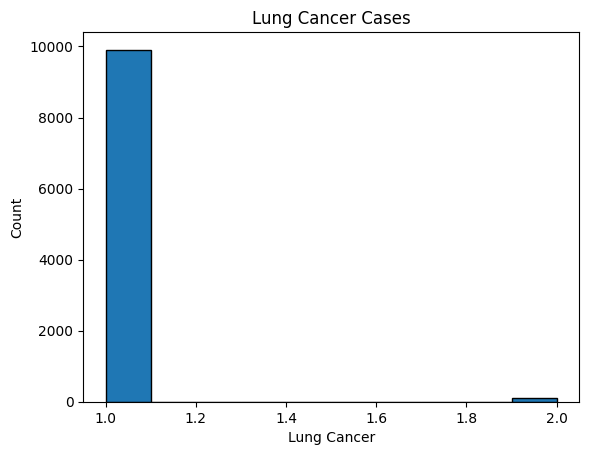

In [9]:
# Q.7) 
!!pip install scikit-learn pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import BernoulliNB

df = pd.read_csv("asia_data.csv")
X = df.drop("V4", axis=1)
y = df["V4"]

model = BernoulliNB()
model.fit(X, y)
sample = [[1,1,0,0,1,0,1]]
prob = model.predict_proba(sample)

print("P(No Lung Cancer):", prob[0][0])
print("P(Yes Lung Cancer):", prob[0][1])
print("Predicted Lung Cancer:", model.predict(sample)[0])

plt.hist(y, edgecolor="black")
plt.title("Lung Cancer Cases")
plt.xlabel("Lung Cancer")
plt.ylabel("Count")
plt.show()

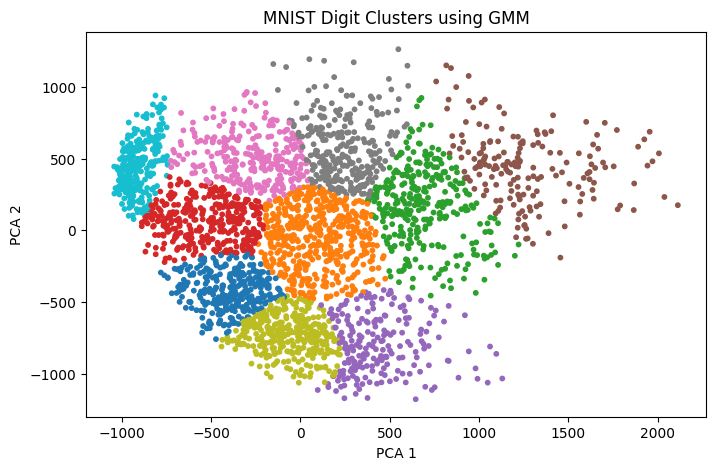

Cluster Labels (first 10): [7 5 8 9 8 1 3 2 3 0]
Means Shape: (10, 2)
Total Samples: 3000


In [11]:
# Q.8) 

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

train = pd.read_csv("8_mnist_train.csv").head(2000)
test = pd.read_csv("8_mnist_test.csv").head(1000)
df = pd.concat([train, test])

X = df.drop("label", axis=1)
X2 = PCA(n_components=2).fit_transform(X)
model = GaussianMixture(n_components=10)
model.fit(X2)
clusters = model.predict(X2)

plt.figure(figsize=(8,5))
plt.scatter(X2[:,0], X2[:,1], c=clusters, cmap='tab10', s=10)
plt.title("MNIST Digit Clusters using GMM")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

print("Cluster Labels (first 10):", clusters[:10])
print("Means Shape:", model.means_.shape)  
print("Total Samples:", len(X))

KNN Accuracy: 1.0
Decision Tree Accuracy: 1.0


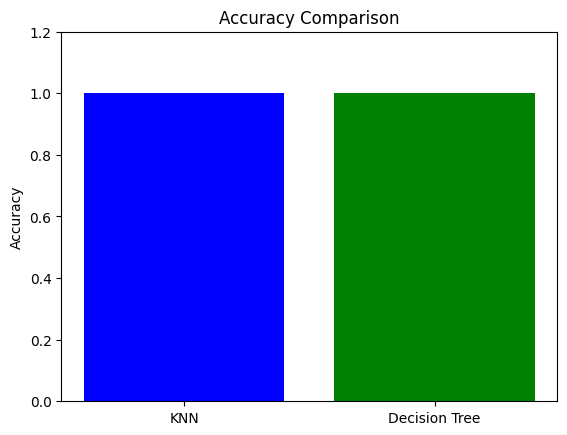

KNN Prediction: Square
DT Prediction: Square


In [12]:
# Q.9) 

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train = [[1,1,1,1], [2,2,2,2], [3,3,3,3]]
y_train = ["Circle", "Square", "Triangle"]

X_test  = [[1,1,1,0], [2,2,2,1], [3,3,3,2]]
y_test  = ["Circle", "Square", "Triangle"]

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
pred1 = knn.predict(X_test)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred2 = dt.predict(X_test)
acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)

print("KNN Accuracy:", acc1)
print("Decision Tree Accuracy:", acc2)

plt.bar(["KNN", "Decision Tree"], [acc1, acc2], color=["blue", "green"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.2)
plt.show()

print("KNN Prediction:", knn.predict([[2,2,2,1]])[0])
print("DT Prediction:", dt.predict([[2,2,2,1]])[0])

K = 1 Accuracy = 0.9466666666666667
K = 3 Accuracy = 0.96
K = 5 Accuracy = 0.96


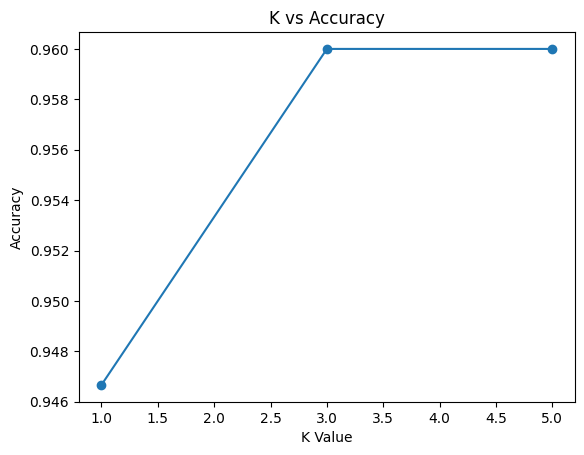

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Features & target
X = df.drop("species", axis=1)
y = df["species"]

# Split
xt, xtst, yt, ytst = train_test_split(X, y, test_size=0.5)

# Try different K values
k_values = [1, 3, 5]
acc = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(xt, yt)
    score = model.score(xtst, ytst)
    acc.append(score)
    print("K =", k, "Accuracy =", score)

# Plot
plt.plot(k_values, acc, marker="o")
plt.title("K vs Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()